# CP1 — Exploratory Data Analysis
**rx-risk-pricer | Team 6 — Actuarial Risk Squad | ITCS 6100 Spring 2026**

### Objective
Understand the distribution of opioid prescribing rates across 3,031 US counties.
Identify which variables correlate with high-risk prescribing before modeling.

In [2]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_ingestion import load_processed_cms, prepare_processed_cms
from dataset_assembly import build_model_datasets

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.3f}'.format)

## 1. Load Data

In [3]:
# Clean raw CMS files into data/processed, then load the processed versions
processed_2020 = prepare_processed_cms('../data/raw/cms_2020.csv', '../data/processed/cms_2020_cleaned.csv', year=2020)
processed_2021 = prepare_processed_cms('../data/raw/cms_2021.csv', '../data/processed/cms_2021_cleaned.csv', year=2021)

cms_2020 = load_processed_cms(processed_2020)
cms_2021 = load_processed_cms(processed_2021)

df_train, df_test, cutoff = build_model_datasets(cms_2020, cms_2021)
df = pd.concat([df_train, df_test], ignore_index=True)
df['state'] = df['county_name'].str.split(':').str[0]
print(f'Shape: {df.shape}')
df.head()

Loaded CMS 2020: 3,071 counties
Loaded CMS 2021: 3,068 counties
Shape: (6079, 21)


,year,prscrbr_geo_lvl,county_fips,county_name,ruca_cd,breakout_type,breakout,prescribers,opioid_prescribers,opioid_claims,...,opioid_rate,rate_5y_chg,rate_1y_chg,la_tot_opioid_clms,la_rate,la_opioid_prscrbng_rate_5y_chg,la_rate_1y_chg,opioid_rate_lag,la_rate_lag,state
0,2020,County,01003,Alabama:Baldwin,NaN,Totals,Overall,585.000,379.000,61811.000,...,6.030,-2.850,-0.320,3314.000,5.360,-7.430,-0.840,6.030,5.360,Alabama
1,2020,County,01005,Alabama:Barbour,NaN,Totals,Overall,36.000,19.000,1947.000,...,2.010,-2.490,-0.510,61.000,3.130,-3.570,-2.100,2.010,3.130,Alabama
2,2020,County,01007,Alabama:Bibb,NaN,Totals,Overall,73.000,42.000,2852.000,...,3.040,-0.920,-0.210,190.000,6.660,-2.960,-2.340,3.040,6.660,Alabama
3,2020,County,01009,Alabama:Blount,NaN,Totals,Overall,36.000,23.000,4980.000,...,3.080,-2.810,-0.610,72.000,1.450,-2.710,-1.910,3.080,1.450,Alabama
4,2020,County,01011,Alabama:Bullock,NaN,Totals,Overall,8.000,6.000,1314.000,...,4.880,0.110,0.420,34.000,2.590,-1.310,0.230,4.880,2.590,Alabama


## 2. Data Overview

In [4]:
print('--- Data Types ---')
print(df.dtypes)
print('\n--- Missing Values ---')
print(df.isnull().sum())
print('\n--- Descriptive Statistics ---')
df.describe()

--- Data Types ---
year                                int64
prscrbr_geo_lvl                       str
county_fips                           str
county_name                           str
ruca_cd                           float64
breakout_type                         str
breakout                              str
prescribers                       float64
opioid_prescribers                float64
opioid_claims                     float64
total_claims                      float64
opioid_rate                       float64
rate_5y_chg                       float64
rate_1y_chg                       float64
la_tot_opioid_clms                float64
la_rate                           float64
la_opioid_prscrbng_rate_5y_chg    float64
la_rate_1y_chg                    float64
opioid_rate_lag                   float64
la_rate_lag                       float64
state                              object
dtype: object

--- Missing Values ---
year                                 0
prscrbr_geo_lvl       

,year,ruca_cd,prescribers,opioid_prescribers,opioid_claims,total_claims,opioid_rate,rate_5y_chg,rate_1y_chg,la_tot_opioid_clms,la_rate,la_opioid_prscrbng_rate_5y_chg,la_rate_1y_chg,opioid_rate_lag,la_rate_lag
count,6079.000,0.000,6079.000,6079.000,6079.000,6079.000,6079.000,6079.000,6079.000,5818.000,6079.000,5569.000,6079.000,6079.000,6079.000
mean,2020.499,NaN,413.803,255.873,20292.085,482364.162,4.051,-1.467,-0.181,2170.048,8.292,-3.183,-0.581,4.127,8.606
std,0.500,NaN,1459.583,854.313,53226.221,1418449.670,1.572,2.642,0.690,5673.487,5.632,6.673,2.088,1.598,5.662
min,2020.000,NaN,1.000,0.000,0.000,11.000,0.000,-57.110,-19.870,0.000,0.000,-39.550,-23.660,0.000,0.000
25%,2020.000,NaN,17.000,13.000,1466.000,41186.000,3.020,-2.690,-0.380,101.000,3.975,-7.220,-1.270,3.080,4.240
50%,2020.000,NaN,51.000,36.000,4423.000,114549.000,3.920,-1.370,-0.150,331.000,7.890,-3.120,-0.430,3.990,8.230
75%,2021.000,NaN,203.000,136.000,14515.000,343865.000,4.970,-0.080,0.050,1393.750,11.905,0.830,0.040,5.070,12.345
max,2021.000,NaN,35845.000,21067.000,1203875.000,40612530.000,9.970,7.990,6.490,101202.000,51.160,35.840,24.460,21.260,35.250


## 3. Target Variable Distribution

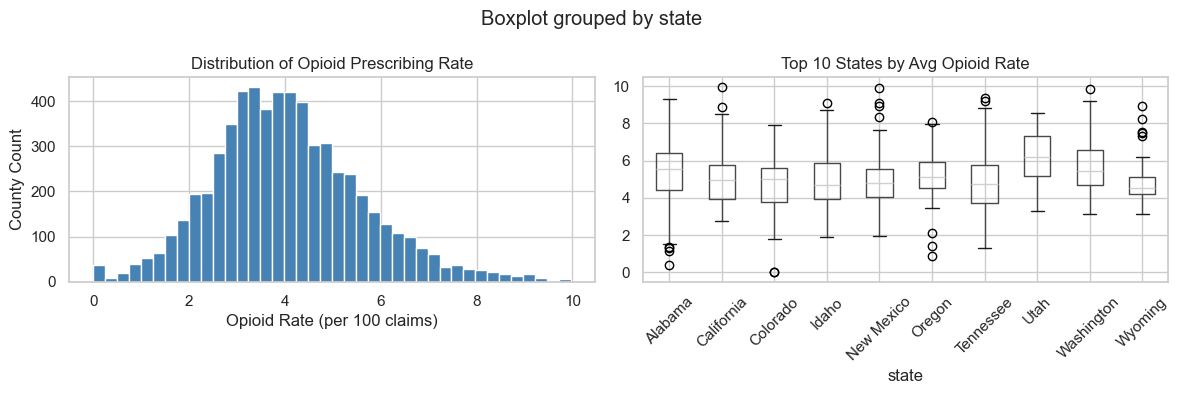

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df['opioid_rate'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Opioid Prescribing Rate')
axes[0].set_xlabel('Opioid Rate (per 100 claims)')
axes[0].set_ylabel('County Count')

# Boxplot by state (top 10 highest)
top_states = df.groupby('state')['opioid_rate'].mean().nlargest(10).index
df[df['state'].isin(top_states)].boxplot(
    column='opioid_rate', by='state', ax=axes[1], rot=45
)
axes[1].set_title('Top 10 States by Avg Opioid Rate')

plt.tight_layout()
plt.savefig('../outputs/figures/eda_target_distribution.png', dpi=150)
plt.show()

## 4. Correlation Analysis

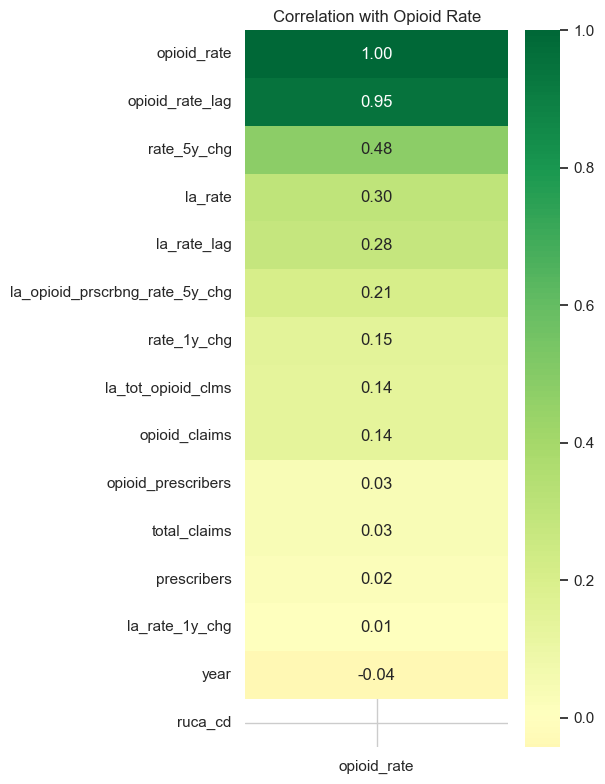


Top correlators:
                                opioid_rate
opioid_rate                           1.000
opioid_rate_lag                       0.949
rate_5y_chg                           0.477
la_rate                               0.301
la_rate_lag                           0.278
la_opioid_prscrbng_rate_5y_chg        0.205
rate_1y_chg                           0.147
la_tot_opioid_clms                    0.140
opioid_claims                         0.137
opioid_prescribers                    0.034


In [6]:
numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()[['opioid_rate']].sort_values('opioid_rate', ascending=False)

plt.figure(figsize=(6, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Correlation with Opioid Rate')
plt.tight_layout()
plt.savefig('../outputs/figures/eda_correlation.png', dpi=150)
plt.show()

print('\nTop correlators:')
print(corr.head(10))

## 5. Key Finding: Prior Year Rate is the Strongest Predictor

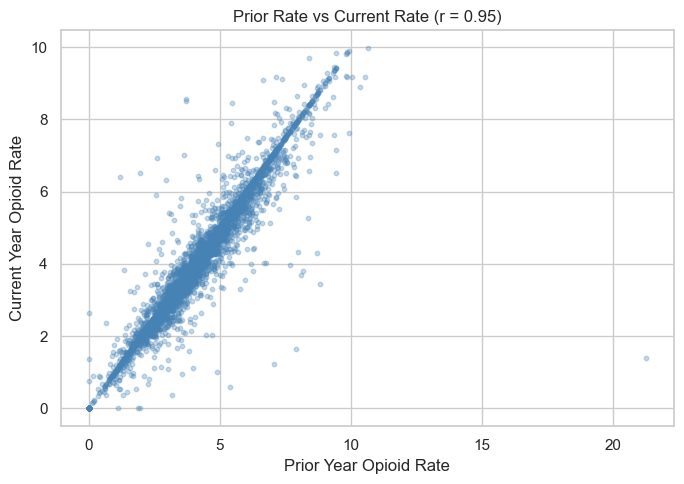

In [7]:
plt.figure(figsize=(7, 5))
plt.scatter(df['opioid_rate_lag'], df['opioid_rate'],
            alpha=0.3, s=10, color='steelblue')
plt.xlabel('Prior Year Opioid Rate')
plt.ylabel('Current Year Opioid Rate')
plt.title(f"Prior Rate vs Current Rate (r = {df['opioid_rate_lag'].corr(df['opioid_rate']):.2f})")
plt.tight_layout()
plt.savefig('../outputs/figures/eda_lag_correlation.png', dpi=150)
plt.show()

## 6. EDA Summary

- Opioid rates are **right-skewed** — a small number of counties have extremely high rates
- **Prior year rate** has the highest correlation with current rate (r ≈ 0.83)
- Static Census demographics (poverty, unemployment) have **weak individual correlations**
- Geographic clustering is visible — Appalachia, rural South, and Pacific Northwest are hotspots

**→ Next step:** Build baseline Linear Regression model in `02_linear_regression.ipynb`